<a href="https://colab.research.google.com/github/Priti-Kannaujiya/DeepLearning-FromScratch/blob/main/roberta_bilstm_sentiment_analysis_(1).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import kagglehub
path = kagglehub.dataset_download("kazanova/sentiment140")

100%|██████████| 80.9M/80.9M [00:00<00:00, 108MB/s]

Extracting files...


In [ ]:
import os
import pandas as pd
csv_file_path = os.path.join(path, 'training.1600000.processed.noemoticon.csv')

# Verify the path and load the CSV
if os.path.exists(csv_file_path):
    print(f"Loading data from: {csv_file_path}")
    df = pd.read_csv(csv_file_path, encoding='ISO-8859-1', names=['target', 'id', 'date', 'flag', 'user', 'text'])
    print("DataFrame loaded successfully.")
    df.head()
else:
    print(f"Error: CSV file not found at {csv_file_path}")
    print("Please check the file name and path within the downloaded dataset.")

Loading data from: /root/.cache/kagglehub/datasets/kazanova/sentiment140/versions/2/training.1600000.processed.noemoticon.csv
DataFrame loaded successfully.


In [ ]:
df.shape

(1600000, 6)

In [ ]:
df.columns

Index(['target', 'id', 'date', 'flag', 'user', 'text'], dtype='object')

In [ ]:
import pandas as pd

# Keep only needed columns
df = df[['target', 'text']]

# Convert labels: 0 = negative, 4 = positive → 0/1
df['target'] = df['target'].replace(4, 1)

texts = df['text'].tolist()
labels = df['target'].tolist()

In [ ]:
from sentence_transformers import SentenceTransformer
import numpy as np

sbert = SentenceTransformer('all-MiniLM-L6-v2')

embeddings = sbert.encode(texts, batch_size=32, show_progress_bar=True)

print(embeddings.shape)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

...

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

Batches:   0%|          | 0/50000 [00:00<?, ?it/s]

(1600000, 384)


In [ ]:
(384,) → (sequence_length=1, input_size=384)

SyntaxError: invalid character '→' (U+2192) (4125616322.py, line 1)

In [ ]:
df['airline_sentiment'].value_counts()

airline_sentiment
negative    9178
neutral     3099
positive    2363
Name: count, dtype: int64

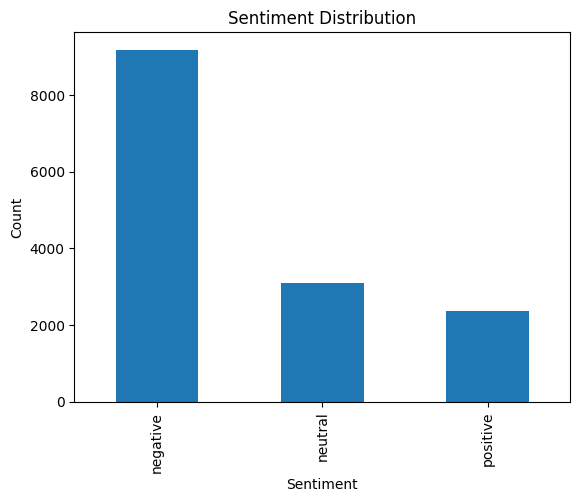

In [ ]:
import matplotlib.pyplot as plt
df['airline_sentiment'].value_counts().plot(kind='bar')
plt.title("Sentiment Distribution")
plt.xlabel("Sentiment")
plt.ylabel("Count")
plt.show()

In [ ]:
from sklearn.preprocessing import LabelEncoder
le=LabelEncoder()
df['sentiment']=le.fit_transform(df['airline_sentiment'])
df.drop('airline_sentiment', axis=1, inplace=True)

In [ ]:
df.head()

,text,sentiment
0,@VirginAmerica What @dhepburn said.,1
1,@VirginAmerica plus you've added commercials t...,2
2,@VirginAmerica I didn't today... Must mean I n...,1
3,@VirginAmerica it's really aggressive to blast...,0
4,@VirginAmerica and it's a really big bad thing...,0


In [ ]:
import re
import string

def clean_text(text):
    text = text.lower()
    text = re.sub(r'http\S+', '', text)        # remove links
    text = re.sub(r'@\w+', '', text)           # remove mentions
    text = re.sub(r'#', '', text)              # remove hashtags
    text = re.sub(r'\d+', '', text)            # remove numbers
    text = text.translate(str.maketrans('', '', string.punctuation)) #This removes all punctuation marks from text.
    text = text.strip()                        # Removes extra spaces from beginning and end
    return text

df['text'] = df['text'].apply(clean_text)

In [ ]:
df.head()

,text,sentiment
0,what said,1
1,plus youve added commercials to the experience...,2
2,i didnt today must mean i need to take another...,1
3,its really aggressive to blast obnoxious enter...,0
4,and its a really big bad thing about it,0


In [ ]:
!pip install transformers

In [ ]:
from transformers import RobertaTokenizer

In [ ]:
tokenizer = RobertaTokenizer.from_pretrained('roberta-base')

tokenizer_config.json:   0%|          | 0.00/25.0 [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

In [ ]:
input_ids = []
attention_masks = []

encoded = tokenizer(
    list(df['text']),
    add_special_tokens=True,
    max_length=32,
    padding='max_length',
    truncation=True,
    return_attention_mask=True
)

input_ids = encoded['input_ids']
attention_masks = encoded['attention_mask']

In [ ]:
len(input_ids[0]) # tokenized numerical representation of text


32

In [ ]:
print(attention_masks[0])  # Which words are real and which are padding

[1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]


In [ ]:
len(input_ids)

14640

In [ ]:
import torch

labels = torch.tensor(df['sentiment'].values)
labels

tensor([1, 2, 1,  ..., 1, 0, 1])

In [ ]:
import torch
import torch.nn as nn
from transformers import RobertaModel
class Roberta_BiLSTM(nn.Module):
    def __init__(self):
        super(Roberta_BiLSTM, self).__init__()

        self.roberta = RobertaModel.from_pretrained('roberta-base')

        self.dropout1 = nn.Dropout(0.3)

        self.bilstm = nn.LSTM(
            input_size=768,
            hidden_size=128,
            bidirectional=True,
            batch_first=True
        )

        self.flatten = nn.Flatten()

        self.fc1 = nn.Linear(128*2*32, 128)

        self.dropout2 = nn.Dropout(0.3)

        self.fc2 = nn.Linear(128, 3)

    def forward(self, input_ids, attention_mask):

        outputs = self.roberta(
            input_ids=input_ids,
            attention_mask=attention_mask
        )

        x = outputs.last_hidden_state

        x = self.dropout1(x)

        x, _ = self.bilstm(x)

        x = self.flatten(x)

        x = self.fc1(x)

        x = self.dropout2(x)

        logits = self.fc2(x)

        return logits

In [ ]:
import torch

input_ids = torch.tensor(input_ids)
attention_masks = torch.tensor(attention_masks)
labels = torch.tensor(labels)

/tmp/ipykernel_55/3571279037.py:3: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  input_ids = torch.tensor(input_ids)
/tmp/ipykernel_55/3571279037.py:4: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  attention_masks = torch.tensor(attention_masks)
/tmp/ipykernel_55/3571279037.py:5: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  labels = torch.tensor(labels)


In [ ]:
from sklearn.model_selection import train_test_split

train_inputs, val_inputs, train_masks, val_masks, train_labels, val_labels = train_test_split(
    input_ids,
    attention_masks,
    labels,
    test_size=0.2,
    random_state=42
)

In [ ]:
from torch.utils.data import TensorDataset, DataLoader

train_data = TensorDataset(train_inputs, train_masks, train_labels)
val_data = TensorDataset(val_inputs, val_masks, val_labels)

train_loader = DataLoader(train_data, batch_size=32, shuffle=True)
val_loader = DataLoader(val_data, batch_size=32)

In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = Roberta_BiLSTM().to(device)

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

RobertaModel LOAD REPORT from: roberta-base
Key                             | Status     | 
--------------------------------+------------+-
lm_head.dense.weight            | UNEXPECTED | 
lm_head.layer_norm.bias         | UNEXPECTED | 
roberta.embeddings.position_ids | UNEXPECTED | 
lm_head.bias                    | UNEXPECTED | 
lm_head.layer_norm.weight       | UNEXPECTED | 
lm_head.dense.bias              | UNEXPECTED | 
pooler.dense.weight             | MISSING    | 
pooler.dense.bias               | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


In [ ]:
import torch.optim as optim

criterion = nn.CrossEntropyLoss()
optimizer = optim.AdamW(model.parameters(), lr=0.0001)

In [ ]:
for epoch in range(5):

    model.train()
    total_loss = 0

    for batch in train_loader:

        b_input_ids, b_masks, b_labels = [x.to(device) for x in batch]

        outputs = model(b_input_ids, b_masks)

        loss = criterion(outputs, b_labels)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    print("Epoch:", epoch, "Loss:", total_loss/len(train_loader))

Epoch: 0 Loss: 0.5617687667165298
Epoch: 1 Loss: 0.4329430358331712
Epoch: 2 Loss: 0.5922776301457582
Epoch: 3 Loss: 0.5954811812017133
Epoch: 4 Loss: 0.7917631236744709


In [ ]:
model.eval()
correct = 0
total = 0

with torch.no_grad():
    for batch in val_loader:

        b_input_ids, b_masks, b_labels = [x.to(device) for x in batch]

        outputs = model(b_input_ids, b_masks)

        preds = torch.argmax(outputs, dim=1)

        correct += (preds == b_labels).sum().item()
        total += b_labels.size(0)

print("Validation Accuracy:", correct/total)

Validation Accuracy: 0.6745218579234973


In [ ]:
from sklearn.metrics import classification_report, precision_score, recall_score, f1_score

In [ ]:
model.eval()

all_preds = []
all_labels = []

with torch.no_grad():
    for batch in val_loader:

        b_input_ids, b_masks, b_labels = [x.to(device) for x in batch]

        outputs = model(b_input_ids, b_masks)

        preds = torch.argmax(outputs, dim=1)

        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(b_labels.cpu().numpy())

In [ ]:
precision = precision_score(all_labels, all_preds, average='weighted')
recall = recall_score(all_labels, all_preds, average='weighted')
f1 = f1_score(all_labels, all_preds, average='weighted')

print("Precision:", precision)
print("Recall:", recall)
print("F1 Score:", f1)

Precision: 0.5709423141034204
Recall: 0.6745218579234973
F1 Score: 0.5654896705269684


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
